In [2]:
!pip install -q --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git

from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
from aeroguard.donnees_ml import colonnes_features, preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
print(vols.shape)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(7473, 137)


In [3]:
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")

print("Features :", len(colonnes_features(vols)))
print("X_train :", X_train.shape, "| X_val :", X_val.shape)
print("\nRépartition dans train (0 = sain, 1 = usé) :")
print(y_train.value_counts(normalize=True).round(3))

Features : 126
X_train : (3716, 126) | X_val : (819, 126)

Répartition dans train (0 = sain, 1 = usé) :
hs
1    0.705
0    0.295
Name: proportion, dtype: float64


In [4]:
from sklearn.dummy import DummyClassifier

bete = DummyClassifier(strategy="most_frequent")
bete.fit(X_train, y_train)                 # il « apprend » juste quelle classe est la plus fréquente
pred_bete = bete.predict(X_val)

print("Le modèle bête répond toujours :", pred_bete[0])
print(f"Bonnes réponses : {(pred_bete == y_val).mean():.1%}")

Le modèle bête répond toujours : 1
Bonnes réponses : 70.2%


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

copieur = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
copieur.fit(X_train, y_train)              # 1. APPRENDRE (avec les corrigés)
pred = copieur.predict(X_val)              # 2. PRÉDIRE (sans les corrigés)

print(f"Bonnes réponses : {(pred == y_val).mean():.1%}")    # 3. NOTER

Bonnes réponses : 79.9%


In [6]:
resultat = vols[vols["groupe"] == "val"][["moteur", "cycle", "RUL", "hs"]].copy()
resultat["vrai"] = y_val.values
resultat["predit"] = pred
resultat["correct"] = resultat["vrai"] == resultat["predit"]

print(resultat.groupby("vrai")["correct"].mean().round(3))     # taux de réussite par vraie classe
resultat[~resultat["correct"]].sort_values("RUL", ascending=False).head(10)

vrai
0    0.693
1    0.843
Name: correct, dtype: float64


,moteur,cycle,RUL,hs,vrai,predit,correct
5182,DS07_2,2,83,1,0,1,False
3075,DS04_6,4,79,1,0,1,False
5186,DS07_2,6,79,1,0,1,False
3076,DS04_6,5,78,1,0,1,False
3500,DS05_1,2,78,1,0,1,False
5188,DS07_2,8,77,1,0,1,False
5189,DS07_2,9,76,1,0,1,False
3078,DS04_6,7,76,1,0,1,False
23,DS01_1,24,76,1,0,1,False
3080,DS04_6,9,74,1,0,1,False


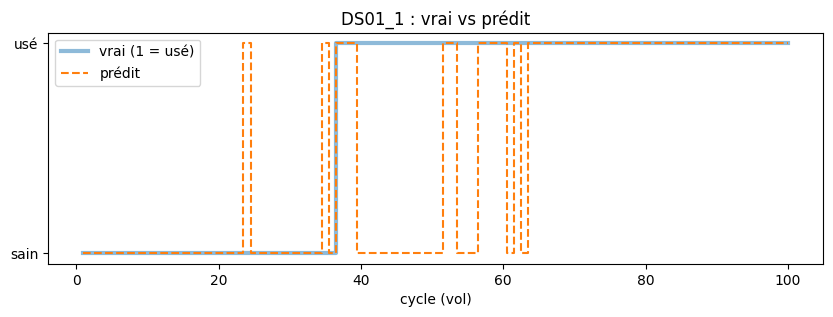

In [7]:
import matplotlib.pyplot as plt

un_moteur = resultat["moteur"].iloc[0]
m = resultat[resultat["moteur"] == un_moteur]

plt.figure(figsize=(10, 3))
plt.step(m["cycle"], m["vrai"], where="mid", label="vrai (1 = usé)", linewidth=3, alpha=0.5)
plt.step(m["cycle"], m["predit"], where="mid", label="prédit", linestyle="--")
plt.yticks([0, 1], ["sain", "usé"])
plt.xlabel("cycle (vol)"); plt.title(f"{un_moteur} : vrai vs prédit"); plt.legend()
plt.show()